Exploratory Data Analysis

This notebook explores the cleaned Amazon Electronics reviews dataset. The goal is to understand the characteristics of the data and determine whether it is suitable for sentiment classification using BERT and review summarization using BART.

In [1]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the processed dataset
df = pd.read_csv("preprocessed_reviews.csv")

In [3]:
# First few rows of the dataset
df.head()

,parent_asin,review_title,text,rating,helpful_vote,verified_purchase,product_title,main_category,average_rating,rating_number,review,sentiment,label,input_text
0,B0995JS7K9,These caneras work great!,Great value,5,0,True,TENVIS 1080P Security Camera - Wireless Camera...,Camera & Photo,4.0,8829,These caneras work great!. Great value,positive,2,These caneras work great! Great value
1,B00HQWLHJI,Fast shipping,"Item was as described, fast shipping.<br />Tha...",5,0,True,10-Pack Enfain 16GB USB 2.0 Flash Memory Stick...,Computers,4.6,10246,"Fast shipping. Item was as described, fast shi...",positive,2,"Fast shipping Item was as described, fast ship..."
2,B07Q1JRKC4,Better than expected,Blew me away,5,0,True,Koss Porta Pro Limited Edition Rhythm Beige On...,All Electronics,4.5,1453,Better than expected. Blew me away,positive,2,Better than expected Blew me away
3,B01MTY7MSK,Four Stars,fits perfect,4,0,True,Kuzy Compatible with MacBook Air 13 inch Case ...,Computers,4.4,6848,Four Stars. fits perfect,positive,2,Four Stars fits perfect
4,B00HQWLHJI,Works great!,It looks like my review will much like the oth...,5,0,True,10-Pack Enfain 16GB USB 2.0 Flash Memory Stick...,Computers,4.6,10246,Works great!. It looks like my review will muc...,positive,2,Works great! It looks like my review will much...


In [4]:
# Shape of the dataset 
df.shape

(48252, 14)

In [5]:
# Dataset columns and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48252 entries, 0 to 48251
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   parent_asin        48252 non-null  str    
 1   review_title       48246 non-null  str    
 2   text               48252 non-null  str    
 3   rating             48252 non-null  int64  
 4   helpful_vote       48252 non-null  int64  
 5   verified_purchase  48252 non-null  bool   
 6   product_title      48252 non-null  str    
 7   main_category      48252 non-null  str    
 8   average_rating     48252 non-null  float64
 9   rating_number      48252 non-null  int64  
 10  review             48252 non-null  str    
 11  sentiment          48252 non-null  str    
 12  label              48252 non-null  int64  
 13  input_text         48252 non-null  str    
dtypes: bool(1), float64(1), int64(4), str(8)
memory usage: 52.8 MB


In [6]:
# Dataset statistics 
df.describe()

,rating,helpful_vote,average_rating,rating_number,label
count,48252.000000,48252.000000,48252.000000,48252.000000,48252.000000
mean,4.024268,1.195474,4.255366,12269.808650,1.549241
std,1.454074,12.172791,0.353435,27593.679869,0.794689
min,1.000000,0.000000,2.300000,2.000000,0.000000
25%,3.000000,0.000000,4.000000,366.000000,1.000000
50%,5.000000,0.000000,4.300000,1803.000000,2.000000
75%,5.000000,0.000000,4.500000,7473.000000,2.000000
max,5.000000,1539.000000,5.000000,168774.000000,2.000000


sentiment
positive    35765
negative     9263
neutral      3224
Name: count, dtype: int64


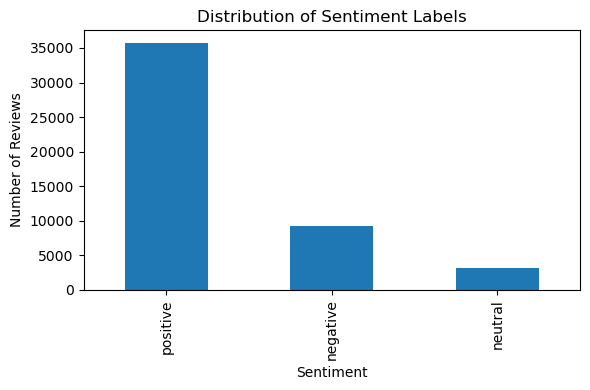

In [7]:
# Count the number of reviews in each sentiment class
sentiment_counts = df["sentiment"].value_counts()

# Display the sentiment counts
print(sentiment_counts)

# Create a bar chart showing the sentiment distribution
plt.figure(figsize=(6, 4))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

The dataset contains reviews from three sentiment classes. Positive reviews are the most common, while neutral reviews are the least represented. This imbalance supports RQ2, which investigates how class balancing techniques affect BERT's performance, particularly for the neutral class.

Rating Distribution

This examines the distribution of product ratings in the cleaned dataset. Since the sentiment labels were derived from the review ratings, this visualization helps verify the underlying rating distribution used for sentiment classification.

rating
1     6475
2     2788
3     3224
4     6369
5    29396
Name: count, dtype: int64


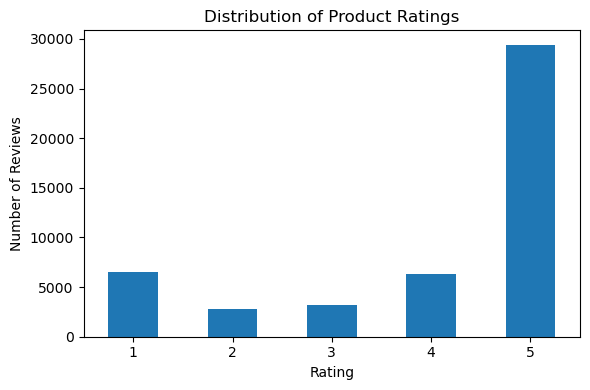

In [8]:
# Count the number of reviews for each rating
rating_counts = df["rating"].value_counts().sort_index()

# Display the rating counts
print(rating_counts)

# Create a bar chart showing the rating distribution
plt.figure(figsize=(6, 4))

rating_counts.plot(kind="bar")

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=360)

plt.tight_layout()
plt.show()

Review Length Analysis

These visualizations examine the distribution of review lengths to understand how much textual information users must process when reading customer reviews. Long and highly variable reviews motivate the need for automatic summarization, which is investigated in RQ1.

In [9]:
# Calculate the length of each review (number of words)
df["review_length"] = df["review"].apply(lambda x: len(str(x).split()))

# Display summary statistics
print(df["review_length"].describe())

# Calculate the 99th percentile of review lengths
# This helps identify the range containing the vast majority of reviews.
review_length_99 = df["review_length"].quantile(0.99)

print("99th percentile:", review_length_99)

count    48252.000000
mean        53.888419
std         82.704600
min          2.000000
25%         14.000000
50%         31.000000
75%         62.000000
max       5945.000000
Name: review_length, dtype: float64
99th percentile: 380.0


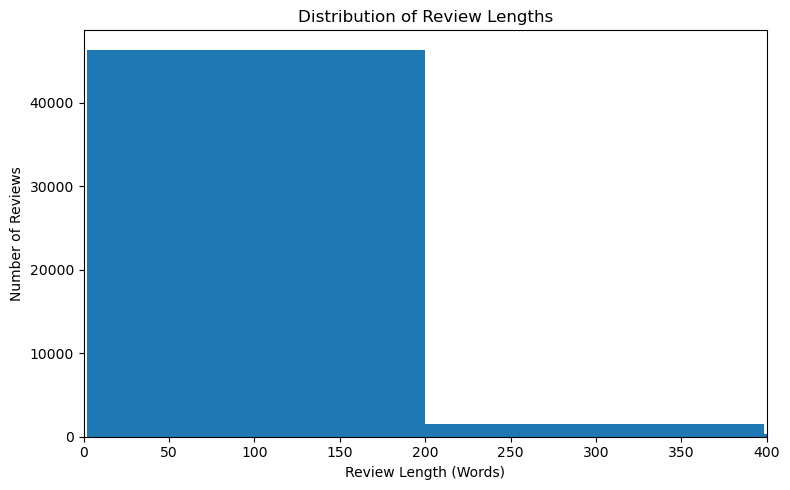

In [10]:
# Plot the distribution of review lengths
plt.figure(figsize=(8, 5))

plt.hist(df["review_length"], bins=30)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (Words)")
plt.ylabel("Number of Reviews")

# The maximum review length is 5,945 words due to a small number of extreme outliers. Since the 99th percentile is approximately 376 words, limiting the x-axis to 400 words allows the histogram to
# clearly display the distribution of nearly all reviews without the outliers compressing the visualization.
plt.xlim(0, 400)

plt.tight_layout()
plt.show()

The histogram shows that review lengths are highly right-skewed, with most reviews containing relatively few words. The x-axis is limited to 400 words because the maximum review length (5,945 words) is caused by a small number of extreme outliers. The 99th percentile of the data is approximately 376 words, meaning that 99% of all reviews contain 376 words or fewer. Limiting the histogram to 400 words improves readability while accurately representing the vast majority of the dataset.

Review Length by Sentiment (Supports Research Question 1)

This visualization compares review lengths across positive, neutral, and negative sentiment categories. Examining review length by sentiment provides additional motivation for automatic review summarization by determining whether consumers may encounter lengthy reviews regardless of the sentiment expressed.

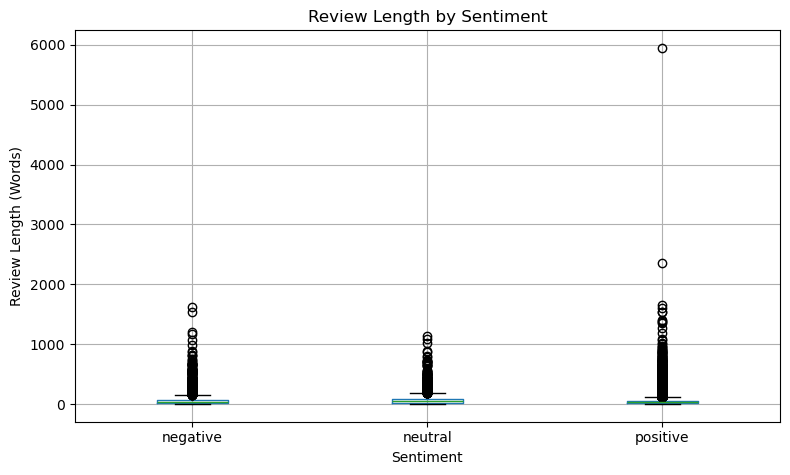

In [11]:
# Create a boxplot comparing review lengths across sentiment categories.
ax = df.boxplot(
    column="review_length",
    by="sentiment",
    figsize=(8,5)
)

# Add a descriptive title and axis labels.
plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the plot.
plt.show()

The boxplot compares review lengths across the three sentiment categories while displaying the full range of review lengths. Although most reviews are relatively short, each sentiment category contains numerous extreme outliers, including reviews exceeding 1,000 words and a small number approaching 6,000 words. These outliers demonstrate why the previous histogram was limited to 400 words: the 99th percentile of review lengths is approximately 376 words, meaning that nearly all reviews fall within this range. Limiting the histogram to 400 words improves readability while accurately representing the vast majority of the dataset, whereas the boxplot highlights the presence of the unusually long reviews.

The previous boxplot demonstrates that the dataset contains several extreme outliers. To better compare the distributions of review lengths across sentiment categories, the following visualization limits the y-axis to 400 words, which includes approximately 99% of all reviews.

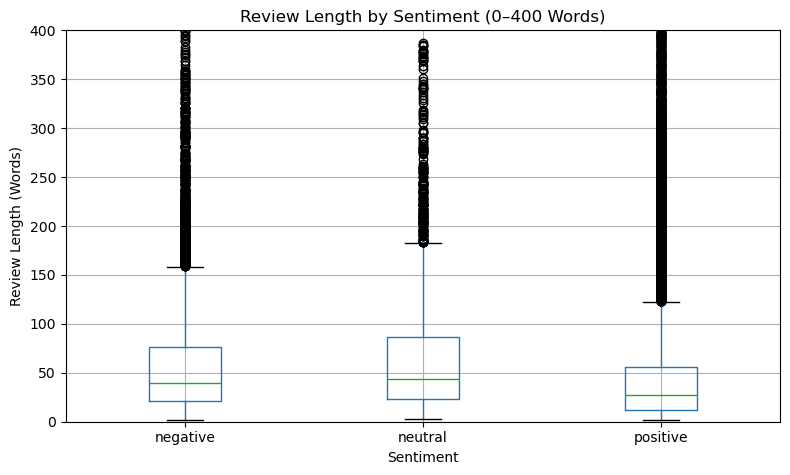

In [12]:
# Create a boxplot comparing review lengths across sentiment categories.
ax = df.boxplot(
    column="review_length",
    by="sentiment",
    figsize=(8,5)
)

# Add a descriptive title and axis labels.
plt.title("Review Length by Sentiment (0–400 Words)")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")

# Limit the y-axis to approximately the 99th percentile of review lengths.
plt.ylim(0, 400)

# Adjust the layout.
plt.tight_layout()

# Display the plot.
plt.show()

The zoomed-in boxplot provides a clearer comparison of review lengths across the three sentiment categories by focusing on reviews between 0 and 400 words, which includes approximately 99% of the dataset. The median review length is slightly higher for neutral reviews than for negative and positive reviews, indicating that neutral reviews tend to be somewhat longer on average. The IQR is also widest for neutral reviews, suggesting greater variability in the middle 50% of review lengths. In contrast, positive reviews have the smallest interquartile range, indicating that their review lengths are more concentrated around the median.

Sentence Count per Review (Supports Research Question 1)

This visualization examines the number of sentences contained in each review. Reviews with more sentences generally require more time and effort to read.

count    48252.000000
mean         5.442282
std          5.863151
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        369.000000
Name: sentence_count, dtype: float64


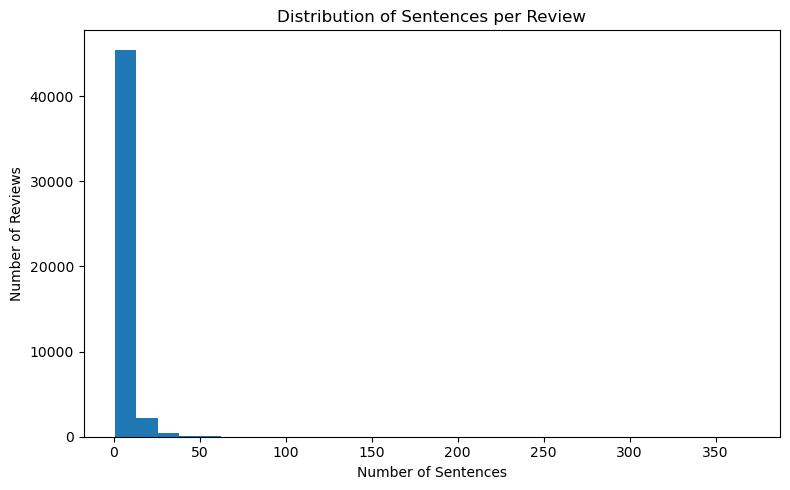

In [13]:
# Estimate the number of sentences in each review by counting periods, question marks, and exclamation points. Reviews with no detected punctuation are assigned a minimum sentence count of one.
df["sentence_count"] = (
    df["review"]
      .astype(str)
      .str.count(r"[.!?]")
      .clip(lower=1)
)

# Display summary statistics for sentence counts.
print(df["sentence_count"].describe())

# Plot the distribution of sentence counts.
plt.figure(figsize=(8,5))

plt.hist(df["sentence_count"], bins=30)

# Add a descriptive title and axis labels.
plt.title("Distribution of Sentences per Review")
plt.xlabel("Number of Sentences")
plt.ylabel("Number of Reviews")

# Adjust the layout.
plt.tight_layout()

# Display the plot.
plt.show()

The histogram shows that the number of sentences per review is heavily right-skewed. Most reviews contain fewer than 10 sentences, indicating that customers typically write relatively concise reviews. However, the distribution also includes a long tail, with a small number of reviews containing substantially more sentences than the majority of the dataset. These longer reviews require more time and effort for consumers to read and understand.

Reviews per Product (Supports Research Question 2)

This visualization examines how many reviews are associated with each product. Products with larger numbers of reviews require more information to be processed during summarization.

count    2285.000000
mean       21.116849
std        77.179476
min         1.000000
25%         3.000000
50%         5.000000
75%        13.000000
max      1373.000000
dtype: float64


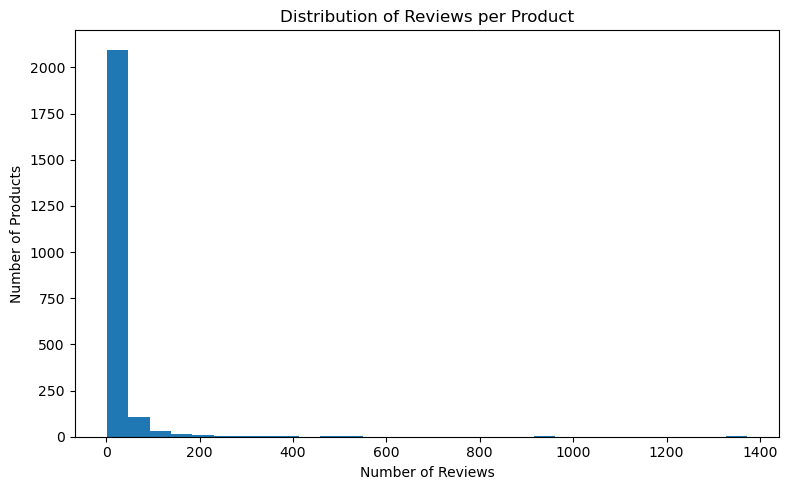

In [14]:
# Count the number of reviews associated with each product.
reviews_per_product = df.groupby("parent_asin").size()

# Display summary statistics.
print(reviews_per_product.describe())

# Plot the distribution.
plt.figure(figsize=(8,5))

plt.hist(reviews_per_product, bins=30)

plt.title("Distribution of Reviews per Product")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.show()

Percentage of reviews exceeding BART's 1024-token limit: 0.11%


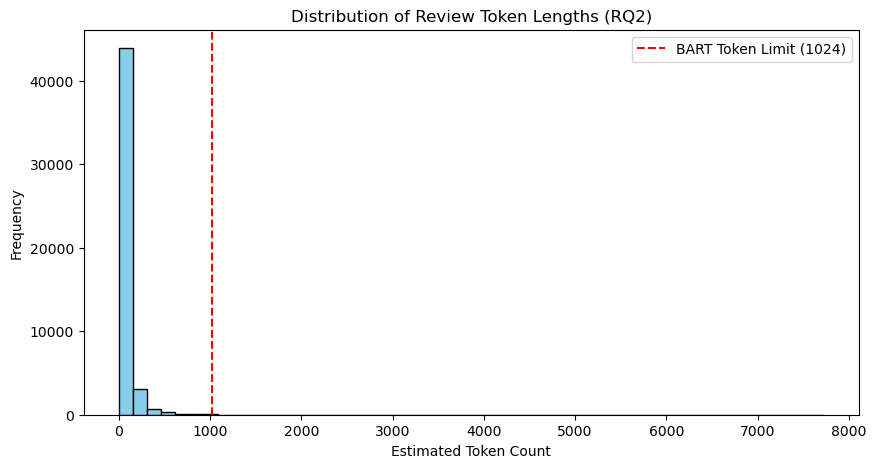

In [16]:
#1 word ≈ 1.3 tokens
df['word_count'] = df['text'].astype(str).str.split().str.len()
df['estimated_tokens'] = (df['word_count'] * 1.3).astype(int)

# Identify products exceeding the BART limit (1024 tokens)
over_limit = df[df['estimated_tokens'] > 1024]
print(f"Percentage of reviews exceeding BART's 1024-token limit: {(len(over_limit)/len(df))*100:.2f}%")

# Visualize the token distribution to show the "Latency" challenge
plt.figure(figsize=(10, 5))
plt.hist(df['estimated_tokens'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(1024, color='red', linestyle='dashed', label='BART Token Limit (1024)')
plt.title("Distribution of Review Token Lengths (RQ2)")
plt.xlabel("Estimated Token Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The average token count is manageable, approximately 64 tokens, and the maximum value of 7,720 tokens significantly exceeds the standard 1,024-token limit for models like BART. Since 0.11% of reviews exceed the 1,024-token threshold establishes the computational boundary for our research. It necessitates an architecture capable of both granular sentiment detection and efficient information distillation. This requirement validates our choice of a BART-based summarization model as the optimal mechanism to condense long-form, high-variance feedback into structured input, thereby ensuring that the BERT sentiment analysis maintains high inference speed and model stability.

Sentiment Correlation with Domain Specific Terms (Supports research question 3)

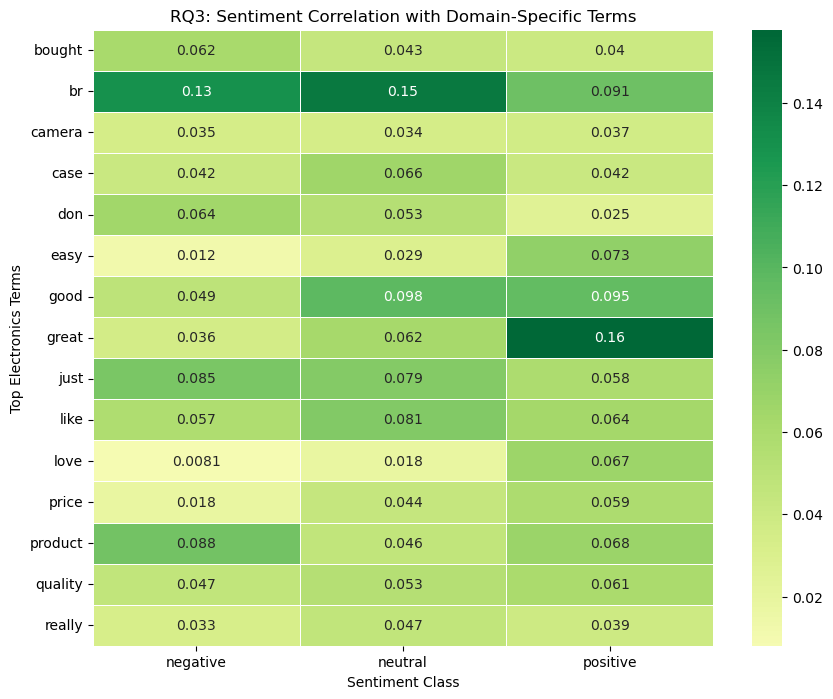

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select top 15 domain-specific words (from your TF-IDF earlier)
top_terms = feature_names[:15] 

# 2. Create a temporary dataframe with only these terms + the sentiment label
# (This assumes you have a 'sentiment' column from your earlier mapping)
temp_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)[top_terms]
temp_df['sentiment'] = df['sentiment'].values

# 3. Compute the correlation matrix
# This shows how strongly each domain term correlates with specific sentiments
corr = temp_df.groupby('sentiment').mean().T

# 4. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, linewidths=.5)
plt.title("RQ3: Sentiment Correlation with Domain-Specific Terms")
plt.ylabel("Top Electronics Terms")
plt.xlabel("Sentiment Class")
plt.show()


Several of the terms show a clear statistical drift across sentiment classes. Terms like "great" (0.157) and "love" (0.067) show a domniant correlation with positive reviews confirming their roles as indicators. Words like "good" (0.097) and "case" (0.066) appear most prominently in the neutral class. Due to this "good" is often used as a neutral descriptor rather than a clear positive, indicating that generic sentiment lexicons may misinterpret this feedback. 